
# TensorFlow Object Detection — End‑to‑End Notebook

**Generated:** 2025-08-27 21:42 UTC  
This notebook gives you a complete, practical workflow for object detection using **TensorFlow**:
1) Environment setup  
2) Quick inference with a pre-trained model from **TensorFlow Hub**  
3) Train a **RetinaNet** detector with **KerasCV** on **Pascal VOC 2007**  
4) Visualize predictions and (optionally) export the model

> Tip: If you're running on CPU, keep epochs small. For best results, use a GPU/TPU runtime.


## 1) Setup

This is a hardcoded block to make sure that everything that is needed for the notebook is running on the exact same version every time, since there was some variance due to versioning.

In [ ]:
# Run as the FIRST cell of the notebook, once per session.
import os, sys, subprocess, textwrap

WANT = {
    "tensorflow": "2.20.0",
    "keras": "3.11.3",
    "keras-cv": "0.9.0",
    "tensorflow-datasets": "4.9.9",
    "tensorflow-hub": "0.16.1",
    "numpy": "1.26.4",
}
AUTO_RESTART = False

def pip_freeze():
    out = subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True)
    installed = {}
    for line in out.splitlines():
        if "==" in line and not line.startswith("-e "):
            name, ver = line.strip().split("==", 1)
            installed[name.lower()] = ver
    return installed

installed = pip_freeze()

# Normalize keys like we pass to pip (hyphen style)
def get_installed(name):
    return installed.get(name.lower())

diff = []
for pkg, want_ver in WANT.items():
    have = get_installed(pkg)
    diff.append((pkg, have, want_ver, have == want_ver))

# Pretty print status
print("\nPackage version check:")
for pkg, have, want, ok in diff:
    mark = "✓" if ok else "✗"
    print(f"  {mark} {pkg:22s} have={str(have):8s} want={want}")

need = [f"{pkg}=={want}" for pkg, have, want, ok in diff if not ok]

if need:
    print("\nInstalling/pinning:", need)
    cmd = [sys.executable, "-m", "pip", "install",
           "--upgrade", "--force-reinstall", "--no-cache-dir", *need]
    print("$", " ".join(cmd))
    # Stream pip output so you can see progress
    subprocess.run(cmd, check=True)
    if AUTO_RESTART:
        print("\nRestarting runtime to load fresh installs…")
        os.kill(os.getpid(), 9)  # expected: Colab disconnects; click Reconnect
    else:
        print("\nPlease do: Runtime → Restart session, then continue.")
else:
    print("\nEnvironment already matches pinned versions. No restart needed.")



Package version check:
  ✓ tensorflow             have=2.20.0   want=2.20.0
  ✓ keras                  have=3.11.3   want=3.11.3
  ✓ keras-cv               have=0.9.0    want=0.9.0
  ✓ tensorflow-datasets    have=4.9.9    want=4.9.9
  ✓ tensorflow-hub         have=0.16.1   want=0.16.1
  ✓ numpy                  have=1.26.4   want=1.26.4

Environment already matches pinned versions. No restart needed.


#### Making sure CUDA is actually working.

In [ ]:
import tensorflow as tf
import logging

# Set logging verbosity to get more details
tf.get_logger().setLevel(logging.INFO)

print("=== TensorFlow Device Listing ===")
print("Physical devices:", tf.config.list_physical_devices())
print("Logical devices:", tf.config.list_logical_devices())

# Optional: Check if CUDA is built and available
print("Built with CUDA:", tf.test.is_built_with_cuda())
# print("CUDA available:", tf.config.experimental.list_physical_devices('GPU')) # Already covered by physical devices above

# Optional: More verbose logging for device placement
# tf.debugging.set_log_device_placement(True)

=== TensorFlow Device Listing ===
Physical devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Logical devices: [LogicalDevice(name='/device:CPU:0', device_type='CPU'), LogicalDevice(name='/device:GPU:0', device_type='GPU')]
Built with CUDA: True


### Anti-variance

I was having issues with variance after making a few changes to my data construction, so this is to hopefully prevent that from now on.

In [ ]:
import os, tensorflow as tf, tensorflow_datasets as tfds
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

### Helper utilities

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def draw_detections(img, boxes, classes, scores, class_names=None, score_threshold=0.3):
    """Draws detections in [ymin, xmin, ymax, xmax] format normalized to [0,1]."""
    h, w = img.shape[0], img.shape[1]
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img)
    for i in range(len(boxes)):
        if scores[i] < score_threshold:
            continue
        ymin, xmin, ymax, xmax = boxes[i]
        x0, y0 = int(xmin*w), int(ymin*h)
        x1, y1 = int(xmax*w), int(ymax*h)
        rect = plt.Rectangle((x0, y0), x1-x0, y1-y0, fill=False, linewidth=2)
        ax.add_patch(rect)
        label = str(classes[i])
        if class_names is not None and int(classes[i]) < len(class_names):
            label = class_names[int(classes[i])]
        ax.text(x0, y0-2, f"{label}: {scores[i]:.2f}", fontsize=10, bbox=dict(facecolor="white", alpha=0.6))
    ax.axis("off")
    plt.show()

def draw_detections_on_image(pil_img, boxes, classes, scores, threshold=0.5):
  W, H = pil_img.size
  fig, ax = plt.subplots(1, figsize=(10, 7))
  ax.imshow(pil_img)

  for i in range(len(scores)):
      score = float(scores[i])
      if score < threshold:
          continue
      cls_id = int(classes[i])
      label = coco_name(cls_id)
      ymin, xmin, ymax, xmax = boxes[i]
      left, top   = xmin * W, ymin * H
      right, bot  = xmax * W, ymax * H
      rect = patches.Rectangle((left, top), right-left, bot-top,
                                linewidth=2, edgecolor="lime", facecolor="none")
      ax.add_patch(rect)
      ax.text(left, max(0, top-6), f"{label} {score:.2f}",
              fontsize=10, color="black",
              bbox=dict(facecolor="yellow", alpha=0.7, edgecolor="none", pad=2))

  plt.axis("off")
  plt.tight_layout()
  plt.show()


## 2) Quick inference with a pre-trained detector (TensorFlow Hub)

/usr/local/lib/python3.12/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


✅ Loaded TF-Hub model: https://tfhub.dev/tensorflow/ssd_mobilenet_v2/fpnlite_320x320/1
✅ Inference complete for image 1: https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg


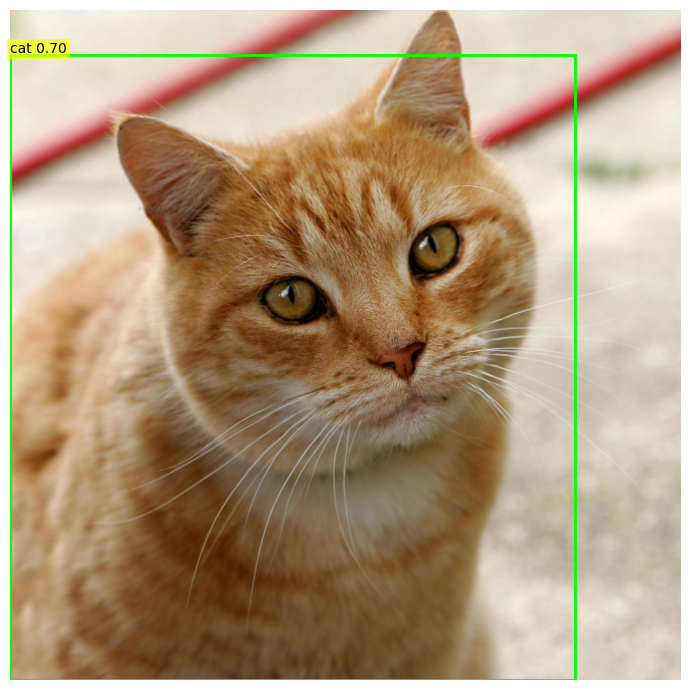

✅ Inference complete for image 2: https://upload.wikimedia.org/wikipedia/commons/6/6e/Golde33443.jpg


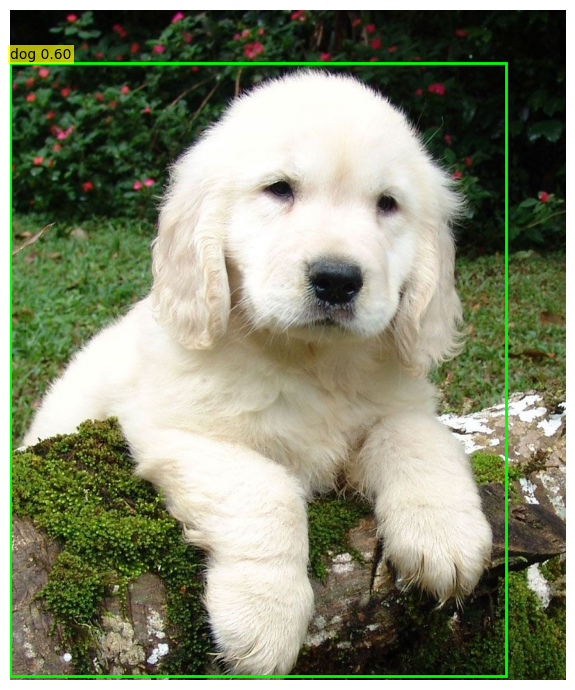

✅ Inference complete for image 3: https://upload.wikimedia.org/wikipedia/commons/4/47/American_Eskimo_Dog.jpg


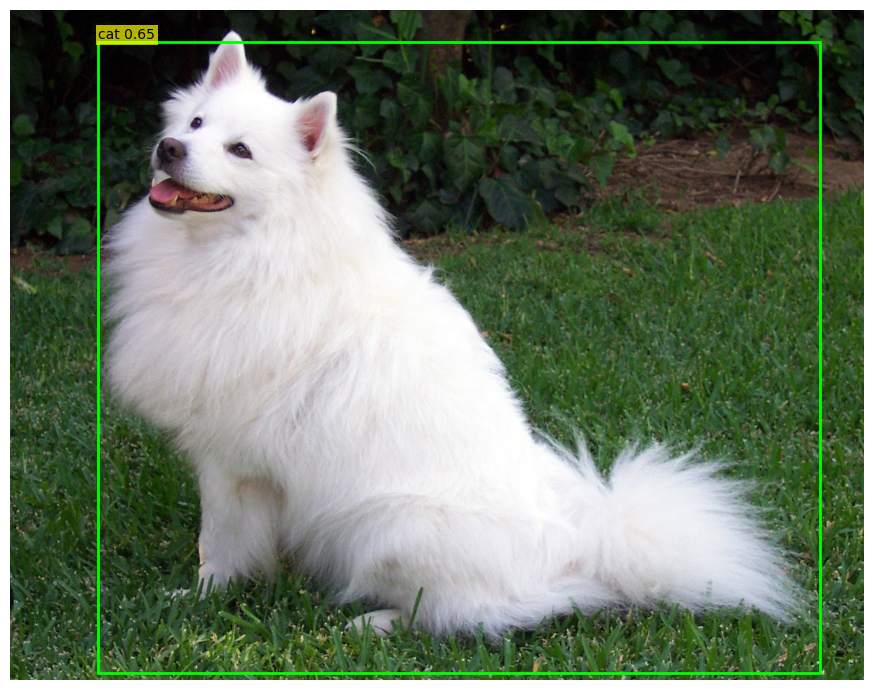

✅ Inference complete for image 4: https://upload.wikimedia.org/wikipedia/commons/thumb/6/6d/Good_Food_Display_-_NCI_Visuals_Online.jpg/640px-Good_Food_Display_-_NCI_Visuals_Online.jpg


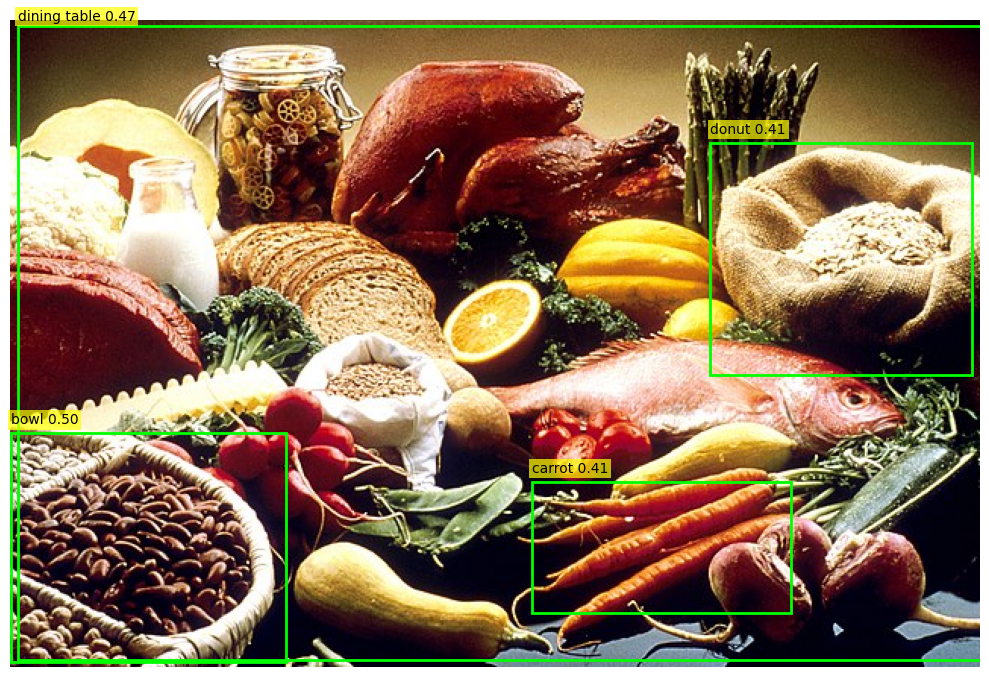

✅ Inference complete for image 5: https://storage.googleapis.com/download.tensorflow.org/example_images/320px-Felis_catus-cat_on_snow.jpg


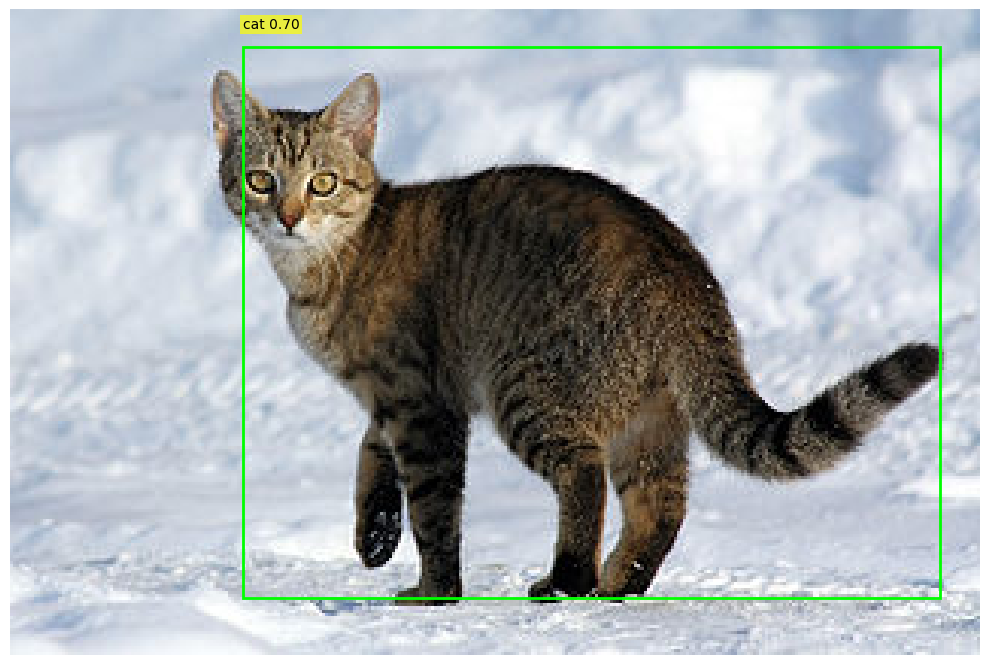

✅ Inference complete for image 6: https://images.unsplash.com/photo-1449824913935-59a10b8d2000?w=640&h=480&fit=crop&crop=center


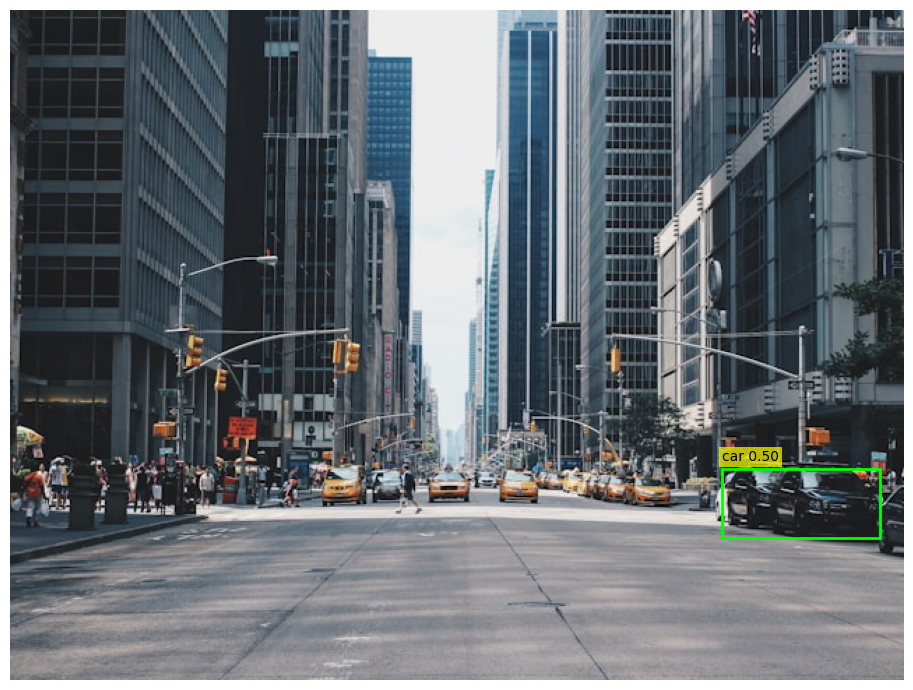

✅ Inference complete for image 7: https://images.unsplash.com/photo-1502920917128-1aa500764cbd?w=640&h=480&fit=crop&crop=center


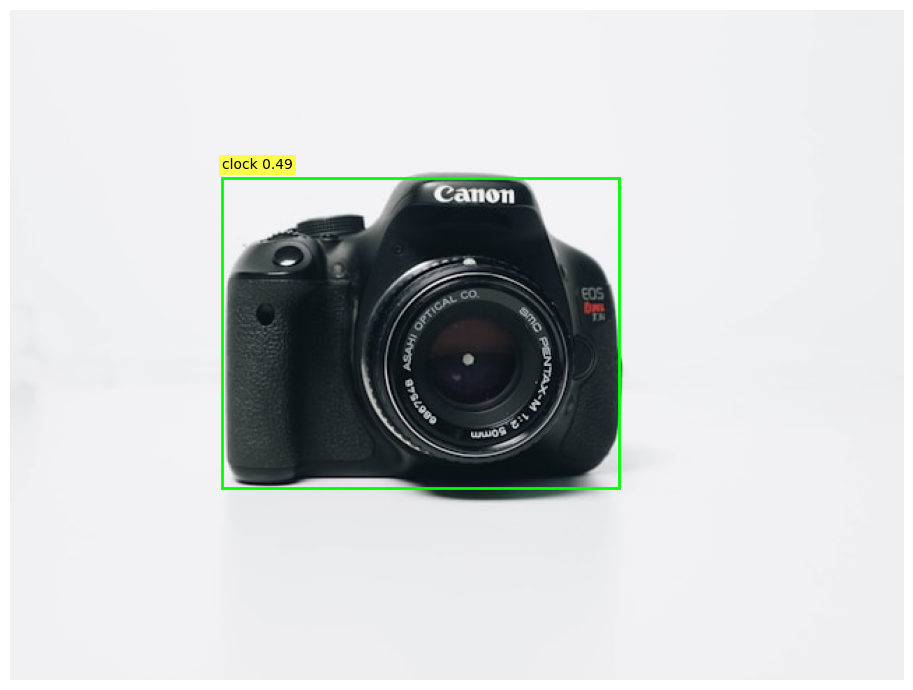

In [ ]:
import io
import requests
import numpy as np
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tensorflow as tf
import tensorflow_hub as hub


# 1) Load TF-Hub model

MODEL_URL = "https://tfhub.dev/tensorflow/ssd_mobilenet_v2/fpnlite_320x320/1"
detector = hub.load(MODEL_URL)
print("✅ Loaded TF-Hub model:", MODEL_URL)

# 2) COCO labels (1..90)

COCO_90 = [
    "???","person","bicycle","car","motorcycle","airplane","bus","train","truck","boat",
    "traffic light","fire hydrant","12","stop sign","parking meter","bench","bird","cat","dog","horse",
    "sheep","cow","elephant","bear","zebra","giraffe","26","backpack","umbrella","29",
    "30","handbag","tie","suitcase","frisbee","skis","snowboard","sports ball","kite","baseball bat",
    "baseball glove","skateboard","surfboard","tennis racket","bottle","45","wine glass","cup","fork",
    "knife","spoon","bowl","banana","apple","sandwich","orange","broccoli","carrot","hot dog","pizza",
    "donut","cake","chair","couch","potted plant","bed","66","dining table","68","69",
    "toilet","71","tv","laptop","mouse","remote","keyboard","cell phone","microwave","oven",
    "toaster","sink","refrigerator","83","book","clock","vase","scissors","teddy bear","hair drier",
    "toothbrush"
]

def coco_name(cls_id:int) -> str:
    return COCO_90[cls_id] if 0 <= cls_id < len(COCO_90) else f"id:{cls_id}"

# 3) Robust image loader

def load_image_from_url(url, model_size=(320, 320)):
    try:
        resp = requests.get(url, timeout=20, headers={"User-Agent": "Mozilla/5.0"})
        resp.raise_for_status()
        if "image" not in resp.headers.get("Content-Type","").lower():
            raise ValueError(f"Non-image content-type ({resp.headers.get('Content-Type')})")

        original = Image.open(io.BytesIO(resp.content)).convert("RGB")
        w, h = original.size
        resized = original.resize(model_size)
        img_for_model = np.array(resized, dtype=np.uint8)
        return img_for_model, original, (w, h)
    except (requests.RequestException, UnidentifiedImageError, ValueError) as e:
        print(f"⚠️ Skipping {url} -> {e}")
        return None, None, None

# 4) Saving image URLs

sample_urls = [
    # Working animal images
    "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg",  # ✅ Works
    "https://upload.wikimedia.org/wikipedia/commons/6/6e/Golde33443.jpg",  # ✅ Works
    "https://upload.wikimedia.org/wikipedia/commons/4/47/American_Eskimo_Dog.jpg",  # ✅ Works

    # Working food/object images
    "https://upload.wikimedia.org/wikipedia/commons/thumb/6/6d/Good_Food_Display_-_NCI_Visuals_Online.jpg/640px-Good_Food_Display_-_NCI_Visuals_Online.jpg",  # ✅ Works

    # Working TensorFlow hosted image
    "https://storage.googleapis.com/download.tensorflow.org/example_images/320px-Felis_catus-cat_on_snow.jpg",  # ✅ Works
    "https://images.unsplash.com/photo-1449824913935-59a10b8d2000?w=640&h=480&fit=crop&crop=center",  # Street scene
    "https://images.unsplash.com/photo-1502920917128-1aa500764cbd?w=640&h=480&fit=crop&crop=center",  # NYC street
]

# 5) Inference + plot

threshold = 0.4

for idx, url in enumerate(sample_urls, start=1):
    img_for_model, original_pil, size = load_image_from_url(url)
    if img_for_model is None:
        print(f"⚠️ Skipping image {idx} due to load error.")
        continue

    input_tensor = tf.convert_to_tensor(img_for_model[None, ...], dtype=tf.uint8)
    outputs = detector(input_tensor)

    boxes   = outputs["detection_boxes"][0].numpy()
    classes = outputs["detection_classes"][0].numpy().astype(int)
    scores  = outputs["detection_scores"][0].numpy()

    print(f"✅ Inference complete for image {idx}: {url}")
    draw_detections_on_image(original_pil, boxes, classes, scores, threshold=threshold)




## 3) Train a RetinaNet detector on Pascal VOC (KerasCV)

### Load Pascal VOC 2007

In [ ]:
# Load Pascal VOC 2007
(ds_list, ds_info) = tfds.load( "voc/2007",
                               split=["train+validation", "test"],
                               with_info=True,
                               shuffle_files=False)
train_ds, val_ds = ds_list

num_classes = ds_info.features["objects"]["label"].num_classes
class_names = ds_info.features["objects"]["label"].names
print("Classes:", num_classes, class_names)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating test examples...: 0 examples [00:00, ? examples/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/voc/2007/incomplete.HBRPOI_5.0.0/voc-train.tfrecord*...:   0%|          | …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/voc/2007/incomplete.HBRPOI_5.0.0/voc-validation.tfrecord*...:   0%|       …

Dataset voc downloaded and prepared to /root/tensorflow_datasets/voc/2007/5.0.0. Subsequent calls will reuse this data.
Classes: 20 ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


### Global Settings

In [ ]:
# Settings
BATCH_SIZE = 10
IMG_SIZE = 480
AUTOTUNE = tf.data.AUTOTUNE
MAX_BOXES = 100

### Preprocessing Function

In [ ]:
def preprocess_sample(sample, training=False):
    """Preprocessing for Pascal VOC with correct box scaling and labels."""

    # Convert image to float32 in [0,1]
    image = tf.cast(sample["image"], tf.float32) / 255.0

    # --- Convert normalized TFDS boxes -> pixel absolute boxes ---
    h = tf.cast(tf.shape(sample["image"])[0], tf.float32)
    w = tf.cast(tf.shape(sample["image"])[1], tf.float32)
    boxes = sample["objects"]["bbox"]  # [ymin, xmin, ymax, xmax] in 0–1
    ymin = boxes[:, 0] * h
    xmin = boxes[:, 1] * w
    ymax = boxes[:, 2] * h
    xmax = boxes[:, 3] * w
    boxes = tf.stack([xmin, ymin, xmax, ymax], axis=1)

    # Labels must be int32 (not float!)
    labels = tf.cast(sample["objects"]["label"], tf.int32)

    # --- Resize image to target size and scale boxes accordingly ---
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    scale_x = IMG_SIZE / w
    scale_y = IMG_SIZE / h
    boxes = boxes * tf.stack([scale_x, scale_y, scale_x, scale_y])

    # --- Data augmentation (only if training) ---
    if training:
        if tf.random.uniform([]) > 0.5:
            image = tf.image.flip_left_right(image)
            width = tf.cast(IMG_SIZE, tf.float32)
            xmin, ymin, xmax, ymax = tf.unstack(boxes, axis=1)
            new_xmin = width - xmax
            new_xmax = width - xmin
            boxes = tf.stack([new_xmin, ymin, new_xmax, ymax], axis=1)

        image = tf.image.random_brightness(image, 0.1)
        image = tf.image.random_contrast(image, 0.9, 1.1)
        image = tf.clip_by_value(image, 0.0, 1.0)

    # --- Pad/truncate boxes & labels ---
    boxes = boxes[:MAX_BOXES]
    labels = labels[:MAX_BOXES]
    actual_boxes = tf.shape(boxes)[0]
    pad_amount = MAX_BOXES - actual_boxes

    # Pad boxes with zeros, labels with -1 (ignored by RetinaNet)
    boxes = tf.cond(
        pad_amount > 0,
        lambda: tf.concat([boxes, tf.zeros([pad_amount, 4], dtype=tf.float32)], axis=0),
        lambda: boxes
    )
    labels = tf.cond(
        pad_amount > 0,
        lambda: tf.concat([labels, tf.fill([pad_amount], -1)], axis=0),
        lambda: labels
    )

    return {
        "images": image,
        "bounding_boxes": {
            "boxes": boxes,
            "classes": labels
        }
    }

### Build Datasets

In [ ]:
opts = tf.data.Options()
opts.deterministic = True

# Build datasets
train = (
    train_ds
    .shuffle(2048, seed=SEED, reshuffle_each_iteration=True)
    .map(lambda x: preprocess_sample(x, training=True), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(AUTOTUNE)
).with_options(opts)

val = (
    val_ds
    .map(lambda x: preprocess_sample(x, training=False), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
).with_options(opts)

print("Steps per epoch (train):", tf.data.experimental.cardinality(train).numpy())
print("Validation steps:", tf.data.experimental.cardinality(val).numpy())

Steps per epoch (train): 501
Validation steps: 496


In [ ]:
v = next(iter(val.take(1)))["images"]
print("val range:", float(tf.reduce_min(v)), float(tf.reduce_max(v)))

val range: 0.0 1.0


### Build Model

Had to add model versioning that's saved to my drive, to make absolutely sure that there's no versioning issues, and so that I can re-run the notebook, without there being some issue with cached weights, models, or anything of that sort.

This also makes it easier for me to iterate over the model, since the baseline model and the best version of the model are separated.

1. Loading the model folder of the drive

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

CKPT_DIR = "/content/drive/MyDrive/ColabFiles/ARTI-450/Obj_Det"
os.makedirs(CKPT_DIR, exist_ok=True)

Mounted at /content/drive


2. Building the model, and loading the baseline version if it exists

In [ ]:
import keras_cv
def build_model():
  backbone = keras_cv.models.ResNet50Backbone.from_preset("resnet50_imagenet")
  return keras_cv.models.RetinaNet(num_classes=num_classes,
                                   bounding_box_format="xyxy",
                                   backbone=backbone)

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=f"{CKPT_DIR}/480_best.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=f"{CKPT_DIR}/480_best.weights.h5",
        monitor="val_loss",
        mode="min",
        save_weights_only=True,
        save_best_only=True),
    # Optionally stop when it plateaus
    # tf.karas.callbacks.EarlyStopping(
    #   monitor="val_loss",
    #   mode="min",
    #   patience=5,
    #   restore_best_weights=True)
]

In [ ]:
from tensorflow.keras import mixed_precision

tf.keras.backend.clear_session()
mixed_precision.set_global_policy("float32")  # or "mixed_float16"

# Build model
model = build_model()

In [ ]:
from tensorflow.keras import mixed_precision

tf.keras.backend.clear_session()
mixed_precision.set_global_policy("float32")  # or "mixed_float16"

# Build model
model = build_model()

INIT_W = f"{CKPT_DIR}/base_init.weights.h5"

if not tf.io.gfile.exists(INIT_W):
  model.save_weights(INIT_W)
  print("Saved baseline init: ", INIT_W)
else:
  model.load_weights(INIT_W)
  print("Loaded baseline init: ", INIT_W)

3. Compile and load the callbacks (saved version/weights) for the model.

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [ ]:
# Starting with backbone frozen
model.backbone.trainable = False

# Compile model (optimizer + losses)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    classification_loss="focal",
    box_loss="smoothl1",
    run_eagerly=False,
    jit_compile=False,
    steps_per_execution=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/trainer.py:212: UserWarning: Model doesn't support `jit_compile=True`. Proceeding with `jit_compile=False`.
  warnings.warn(


4. Train head

In [ ]:
print("Training head with frozen backbone...")
EPOCHS_HEAD = 3
history_head = model.fit(
    train,
    validation_data=val,
    epochs=EPOCHS_HEAD,
    callbacks=None,
    verbose=1
)

Training head with frozen backbone...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(10, 480, 480, 3))
  warnings.warn(msg)


512/501 ━━━━━━━━━━━━━━━━━━━━ -2s 261ms/step - box_loss: 0.4363 - classification_loss: 0.6818 - loss: 1.1181

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 480, 480, 3))
  warnings.warn(msg)


501/501 ━━━━━━━━━━━━━━━━━━━━ 171s 341ms/step - box_loss: 0.4119 - classification_loss: 0.6235 - loss: 1.0354 - val_box_loss: 0.5719 - val_classification_loss: 0.8162 - val_loss: 1.3888
Epoch 2/3
501/501 ━━━━━━━━━━━━━━━━━━━━ 127s 254ms/step - box_loss: 0.4544 - classification_loss: 8.5431 - loss: 8.9974 - val_box_loss: 0.6660 - val_classification_loss: 1.0715 - val_loss: 1.7378
Epoch 3/3
501/501 ━━━━━━━━━━━━━━━━━━━━ 127s 254ms/step - box_loss: 0.5752 - classification_loss: 1.0712 - loss: 1.6464 - val_box_loss: 0.5606 - val_classification_loss: 1.0701 - val_loss: 1.6312


### Unfreeze and fine-tine

In [ ]:
print("Unfreezing backbone for fine-tuning...")

for layer in model.backbone.layers:
    layer.trainable = True

# Recompile with lower learning rate to avoid destroying pretrained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    classification_loss="focal",
    box_loss="smoothl1",
    run_eagerly=False,
    jit_compile=False,
    steps_per_execution=64
)

# Continue training from previous epoch
EPOCHS_TOTAL = 12
history_finetune = model.fit(
    train,
    validation_data=val,
    initial_epoch=EPOCHS_HEAD,
    epochs=EPOCHS_TOTAL,
    callbacks=None,
    verbose=1
)

print("Training complete!")

Unfreezing backbone for fine-tuning...
Epoch 4/12


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(10, 480, 480, 3))
  warnings.warn(msg)


512/501 ━━━━━━━━━━━━━━━━━━━━ -2s 260ms/step - box_loss: 0.5382 - classification_loss: 0.6785 - loss: 1.2167

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 480, 480, 3))
  warnings.warn(msg)


501/501 ━━━━━━━━━━━━━━━━━━━━ 171s 342ms/step - box_loss: 0.5065 - classification_loss: 0.6454 - loss: 1.1519 - val_box_loss: 0.4768 - val_classification_loss: 0.6710 - val_loss: 1.1484
Epoch 5/12
501/501 ━━━━━━━━━━━━━━━━━━━━ 127s 253ms/step - box_loss: 0.3865 - classification_loss: 0.5654 - loss: 0.9519 - val_box_loss: 0.3546 - val_classification_loss: 0.5392 - val_loss: 0.8943
Epoch 6/12
501/501 ━━━━━━━━━━━━━━━━━━━━ 127s 253ms/step - box_loss: 0.3202 - classification_loss: 0.5073 - loss: 0.8275 - val_box_loss: 0.3265 - val_classification_loss: 0.4344 - val_loss: 0.7613
Epoch 7/12
501/501 ━━━━━━━━━━━━━━━━━━━━ 127s 253ms/step - box_loss: 0.2788 - classification_loss: 0.3987 - loss: 0.6775 - val_box_loss: 0.3077 - val_classification_loss: 0.3815 - val_loss: 0.6895
Epoch 8/12
501/501 ━━━━━━━━━━━━━━━━━━━━ 127s 253ms/step - box_loss: 0.2460 - classification_loss: 0.3419 - loss: 0.5879 - val_box_loss: 0.2963 - val_classification_loss: 0.3473 - val_loss: 0.6440
Epoch 9/12
501/501 ━━━━━━━━━━━━

## 4) Iterating on best weights


I've done quite a few runs of the model, with baseline settings that just prevent too much variance. I'm now going to test a few things quickly, with the best saved weights, just to see if any ideas have legs.

In [ ]:
run = "480"
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=f"{CKPT_DIR}/{run}_best.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=f"{CKPT_DIR}/{run}_best.weights.h5",
        monitor="val_loss",
        mode="min",
        save_weights_only=True,
        save_best_only=True),
    # Optionally stop when it plateaus
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True)
]

In [ ]:
# Loading the best weights and instantiating model
BEST_W = f"{CKPT_DIR}/base_best.weights.h5"

model_iter1 = build_model()
model_iter1.load_weights(BEST_W)

opt = tf.keras.optimizers.Adam(4e-5)

# Warm-init compile (no XLA, tiny steps_per_execution)
# --- This is for safety
model_iter1.compile(optimizer=opt,
              classification_loss="focal",
              box_loss="smoothl1",
              run_eagerly=False,
              jit_compile=False,
              steps_per_execution=1)

# Triggering creation of opt slots and train graph
_ = model_iter1.fit(train.take(1), epochs=1, verbose=0)

# Real compile
model_iter1.compile(optimizer=opt,
              classification_loss="focal",
              box_loss="smoothl1",
              run_eagerly=False,
              jit_compile=False,
              steps_per_execution=64)

history_finetune2 = model_iter1.fit(
    train,
    validation_data=val,
    epochs=12,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/12
501/501 ━━━━━━━━━━━━━━━━━━━━ 171s 342ms/step - box_loss: 0.2441 - classification_loss: 0.2451 - loss: 0.4892 - val_box_loss: 0.2792 - val_classification_loss: 0.2709 - val_loss: 0.5505
Epoch 2/12
501/501 ━━━━━━━━━━━━━━━━━━━━ 134s 268ms/step - box_loss: 0.2085 - classification_loss: 0.2112 - loss: 0.4197 - val_box_loss: 0.2746 - val_classification_loss: 0.2646 - val_loss: 0.5396
Epoch 3/12
501/501 ━━━━━━━━━━━━━━━━━━━━ 135s 269ms/step - box_loss: 0.1916 - classification_loss: 0.1912 - loss: 0.3828 - val_box_loss: 0.2700 - val_classification_loss: 0.2653 - val_loss: 0.5357
Epoch 4/12
501/501 ━━━━━━━━━━━━━━━━━━━━ 134s 268ms/step - box_loss: 0.1749 - classification_loss: 0.1731 - loss: 0.3480 - val_box_loss: 0.2712 - val_classification_loss: 0.2588 - val_loss: 0.5302
Epoch 5/12
501/501 ━━━━━━━━━━━━━━━━━━━━ 135s 269ms/step - box_loss: 0.1623 - classification_loss: 0.1596 - loss: 0.3218 - val_box_loss: 0.2672 - val_classification_loss: 0.2591 - val_loss: 0.5266
Epoch 6/12
501/501 ━

In [ ]:
import numpy as np, tensorflow as tf

def collect_preds_and_gts(model, ds, score_min_for_map=0.0, max_images=None):
    """Returns a list of (gt_boxes, gt_classes, pred_boxes, pred_classes, pred_scores) per image."""
    out = []
    seen = 0
    for batch in ds:
        imgs = batch["images"]
        gtb = batch["bounding_boxes"]["boxes"].numpy()
        gtc = batch["bounding_boxes"]["classes"].numpy()

        # Predict WITHOUT XLA (predict ignores jit_compile; you're fine)
        preds = model.predict(imgs, verbose=0)
        pb = preds["boxes"]; pc = preds["classes"].astype(np.int32); ps = preds["confidence"]

        B = pb.shape[0]
        for i in range(B):
            gt_boxes  = gtb[i][gtc[i] >= 0]                       # drop padded
            gt_cls    = gtc[i][gtc[i] >= 0].astype(np.int32)

            # keep preds above a minimal floor when collecting for mAP
            keep = ps[i] >= score_min_for_map
            pred_boxes = pb[i][keep]
            pred_cls   = pc[i][keep]
            pred_scores= ps[i][keep]

            out.append((gt_boxes, gt_cls, pred_boxes, pred_cls, pred_scores))
            seen += 1
            if (max_images is not None) and (seen >= max_images):
                return out
    return out

In [ ]:
def iou_xyxy(box, boxes):
    """box: (4,), boxes: (N,4), all xyxy."""
    x1 = np.maximum(box[0], boxes[:,0]); y1 = np.maximum(box[1], boxes[:,1])
    x2 = np.minimum(box[2], boxes[:,2]); y2 = np.minimum(box[3], boxes[:,3])
    w = np.maximum(0.0, x2 - x1); h = np.maximum(0.0, y2 - y1)
    inter = w * h
    area1 = (box[2]-box[0]) * (box[3]-box[1])
    area2 = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])
    union = np.maximum(1e-9, area1 + area2 - inter)
    return inter / union

def voc_ap(rec, prec):
    """Continuous (area under precision envelope)."""
    mrec = np.concatenate(([0.], rec, [1.]))
    mpre = np.concatenate(([0.], prec, [0.]))
    for i in range(mpre.size-1, 0, -1):
        mpre[i-1] = np.maximum(mpre[i-1], mpre[i])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return np.sum((mrec[idx+1]-mrec[idx]) * mpre[idx+1])

def evaluate_map(stats, num_classes, iou_thr=0.5):
    """stats: list of tuples from collect_preds_and_gts()."""
    aps = np.zeros(num_classes, dtype=np.float32)
    per_class_counts = np.zeros(num_classes, dtype=np.int32)

    # Build GT dicts by image for each class
    # and flat list of predictions (box, score, img_id) per class
    gts = {c: {} for c in range(num_classes)}        # c -> img_id -> (boxes, matched_flags)
    preds = {c: [] for c in range(num_classes)}      # c -> list of (score, img_id, box)

    for img_id, (gtb, gtc, pb, pc, ps) in enumerate(stats):
        # GT
        for c in range(num_classes):
            mask = (gtc == c)
            if mask.any():
                boxes_c = gtb[mask]
                gts[c][img_id] = [boxes_c, np.zeros(len(boxes_c), dtype=bool)]
                per_class_counts[c] += len(boxes_c)
        # Preds
        for c in range(num_classes):
            mask = (pc == c)
            if mask.any():
                for box, score in zip(pb[mask], ps[mask]):
                    preds[c].append((float(score), img_id, box))

    # Compute AP per class
    for c in range(num_classes):
        npos = per_class_counts[c]
        if npos == 0:
            aps[c] = np.nan
            continue
        # sort predictions by score desc
        p = sorted(preds[c], key=lambda x: -x[0])
        tp = np.zeros(len(p), dtype=np.float32)
        fp = np.zeros(len(p), dtype=np.float32)

        for i, (score, img_id, box) in enumerate(p):
            if img_id not in gts[c]:
                fp[i] = 1.0
                continue
            gt_boxes, matched = gts[c][img_id]
            if len(gt_boxes) == 0:
                fp[i] = 1.0
                continue
            ious = iou_xyxy(box, gt_boxes)
            j = int(np.argmax(ious))
            if ious[j] >= iou_thr and not matched[j]:
                tp[i] = 1.0
                matched[j] = True
            else:
                fp[i] = 1.0

        tp_cum = np.cumsum(tp)
        fp_cum = np.cumsum(fp)
        rec = tp_cum / (npos + 1e-9)
        prec = tp_cum / np.maximum(tp_cum + fp_cum, 1e-9)
        aps[c] = voc_ap(rec, prec)

    mAP = np.nanmean(aps)  # ignore classes with no GTs in val
    return aps, float(mAP)

def precision_recall_at_conf(stats, num_classes, conf_thr=0.5, iou_thr=0.5):
    """Micro P/R/F1 at fixed confidence threshold."""
    TP = FP = FN = 0
    for img_id, (gtb, gtc, pb, pc, ps) in enumerate(stats):
        keep = (ps >= conf_thr)
        pb, pc, ps = pb[keep], pc[keep], ps[keep]
        matched = np.zeros(len(gtb), dtype=bool)

        # Greedy matching by descending score
        order = np.argsort(-ps)
        for k in order:
            if len(gtb) == 0:
                FP += 1; continue
            ious = iou_xyxy(pb[k], gtb)
            j = int(np.argmax(ious))
            if (ious[j] >= iou_thr) and (pc[k] == gtc[j]) and (not matched[j]):
                TP += 1; matched[j] = True
            else:
                FP += 1
        FN += int((~matched[gtc >= -1]).sum()) if len(matched)>0 else 0

    prec = TP / max(TP + FP, 1)
    rec  = TP / max(TP + FN, 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-9)
    return {"TP": TP, "FP": FP, "FN": FN, "precision": prec, "recall": rec, "f1": f1}

In [ ]:
# 1) Gather predictions (use score_min_for_map=0.0 to integrate over all scores)
stats = collect_preds_and_gts(model, val, score_min_for_map=0.0, max_images=None)

# 2) mAP@0.5 (VOC-style)
aps, mAP50 = evaluate_map(stats, num_classes, iou_thr=0.5)
print(f"mAP@0.5: {mAP50:.3f}")

# Optional: per-class AP table (top few)
top = np.argsort(-np.nan_to_num(aps, nan=-1.0))[:10]
for idx in top:
    print(f"{class_names[idx]:15s} AP@0.5 = {aps[idx]:.3f}")

# 3) Micro P/R/F1 at a fixed confidence (e.g., 0.5)
fixed = precision_recall_at_conf(stats, num_classes, conf_thr=0.5, iou_thr=0.5)
print(f"@conf≥0.50  P={fixed['precision']:.3f}  R={fixed['recall']:.3f}  F1={fixed['f1']:.3f}  "
      f"(TP={fixed['TP']} FP={fixed['FP']} FN={fixed['FN']})")

KeyboardInterrupt: 

## 5)  Visualize some predictions

First, I need to build a float32 inference copy of the model, since it was trained using float16 for speed. Otherwise, it won't play nice with the visualization.

In [ ]:
from tensorflow.keras import mixed_precision, backend as K

def build_fp32_infer_from(model, num_classes, bounding_box_format="xyxy"):
    # Save current policy
    old_policy = mixed_precision.global_policy().name
    old_floatx = K.floatx()

    # Switch to pure float32 while we BUILD the inference model
    mixed_precision.set_global_policy("float32")
    K.set_floatx("float32")
    try:
        # Recreate the same architecture in float32
        # (Clone sometimes fails with KerasCV models; building explicitly is safer.)
        bb = keras_cv.models.ResNet50Backbone.from_preset("resnet50_imagenet")
        infer_model = keras_cv.models.RetinaNet(
            num_classes=num_classes,
            bounding_box_format=bounding_box_format,
            backbone=bb
        )
        # Load weights from the trained model (variables are float32 already)
        infer_model.set_weights(model.get_weights())
    finally:
        # Restore original global settings for training
        mixed_precision.set_global_policy(old_policy)
        K.set_floatx(old_floatx)
    return infer_model

# Build once (after training) and reuse:
infer_model_fp32 = build_fp32_infer_from(model, num_classes=num_classes)

Now, I can build the visualizations, using the inference model.

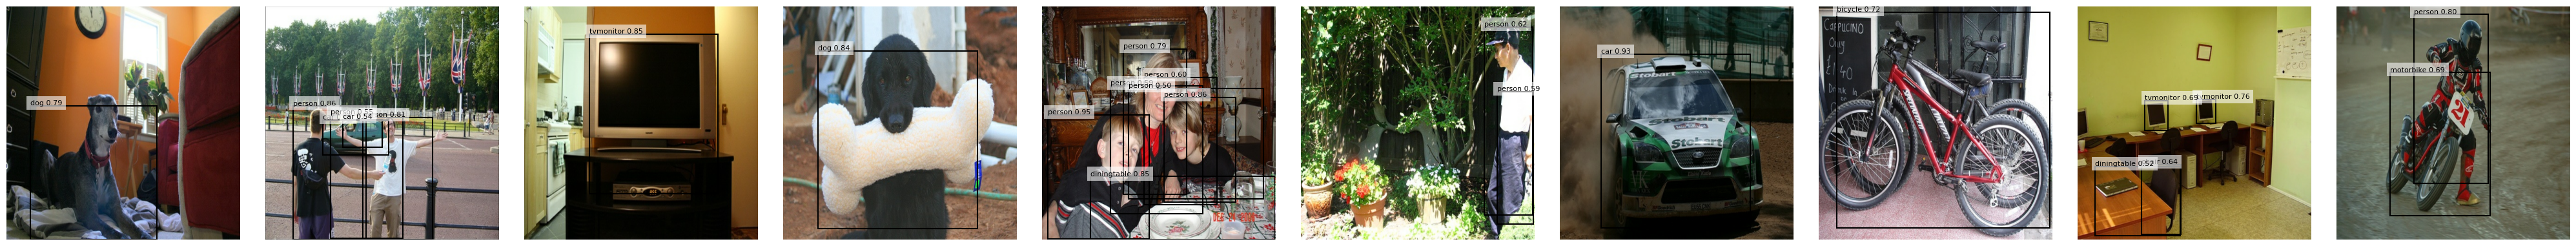

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def viz_matplotlib(ds, pred_model=None, num_images=6, score_threshold=0.35, topk=20, nms_iou=None):
    """Robust Matplotlib visualization for KerasCV RetinaNet outputs."""
    if pred_model is None:
        pred_model = model  # use your trained model by default

    batch = next(iter(ds.take(1)))
    images = tf.cast(batch["images"][:num_images], tf.float32).numpy()  # [0,1]
    preds  = pred_model.predict(images, verbose=0)

    boxes   = preds["boxes"][:num_images]
    classes = preds["classes"][:num_images].astype(np.int32)
    conf    = preds["confidence"][:num_images]

    H, W = images.shape[1:3]

    # 1) Auto-detect normalized boxes and scale to pixels if needed
    if np.nanmax(boxes) <= 1.5:  # likely [0,1]
        boxes = boxes.copy()
        boxes[..., [0, 2]] *= W
        boxes[..., [1, 3]] *= H

    # 2) Choose threshold; default to low (decoder-like) if not provided
    th = 0.05 if score_threshold is None else score_threshold

    cols = num_images
    fig, axes = plt.subplots(1, cols, figsize=(4*cols, 4))
    axes = np.atleast_1d(axes)

    for i, ax in enumerate(axes):
        ax.imshow(np.clip(images[i], 0, 1))
        bx, cl, cf = boxes[i], classes[i], conf[i]

        # keep only valid classes
        valid = cl >= 0
        bx, cl, cf = bx[valid], cl[valid], cf[valid]

        # 3) Optional extra NMS on top of model’s decoder (rarely needed)
        if nms_iou is not None and len(bx):
            # Convert to y1x1y2x2 for tf.image.non_max_suppression
            y1x1y2x2 = np.stack([bx[:,1], bx[:,0], bx[:,3], bx[:,2]], axis=-1).astype(np.float32)
            idx = tf.image.non_max_suppression(y1x1y2x2, cf.astype(np.float32),
                                               max_output_size=min(len(bx), topk),
                                               iou_threshold=nms_iou).numpy()
            bx, cl, cf = bx[idx], cl[idx], cf[idx]

        # 4) Threshold; if nothing passes, draw top-k highest confidence
        idx = np.where(cf >= th)[0]
        if len(idx) == 0 and len(cf) > 0:
            idx = np.argsort(-cf)[:topk]  # top-k fallback

        for j in idx:
            x1, y1, x2, y2 = bx[j]
            # clip to image bounds
            x1, y1 = float(np.clip(x1, 0, W-1)), float(np.clip(y1, 0, H-1))
            x2, y2 = float(np.clip(x2, 0, W-1)), float(np.clip(y2, 0, H-1))
            if x2 <= x1 or y2 <= y1:
                continue
            rect = Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=1.5)
            ax.add_patch(rect)
            ax.text(x1, max(0, y1-2),
                    f"{class_names[cl[j]]} {cf[j]:.2f}",
                    fontsize=8,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))
        ax.axis("off")

    plt.tight_layout()
    plt.show()

viz_matplotlib(val, pred_model=model, num_images=10, score_threshold=0.05, topk=20)

In [ ]:
print(val)

<_OptionsDataset element_spec={'images': TensorSpec(shape=(None, 480, 480, 3), dtype=tf.float32, name=None), 'bounding_boxes': {'boxes': TensorSpec(shape=(None, None, 4), dtype=tf.float32, name=None), 'classes': TensorSpec(shape=(None, None), dtype=tf.int32, name=None)}}>


## 5) Next Iteration

### Adding Augmenter to the training

In [ ]:
# Cell: Augmenters (0–255 value_range)
AUTO = tf.data.AUTOTUNE

augment = keras_cv.layers.Augmenter(layers=[
    # Horizontal flip that updates boxes
    keras_cv.layers.RandomFlip(mode="horizontal", bounding_box_format="xyxy"),
    # Scale jitter + resize back to target
    keras_cv.layers.JitteredResize(
        target_size=(IMG_SIZE, IMG_SIZE),
        scale_factor=(0.8, 1.25),                 # try (0.7, 1.35) if you want stronger
        bounding_box_format="xyxy",
    ),
    # Light color jitter (tuned for 0–255 images)
    keras_cv.layers.RandomColorJitter(
        value_range=(0, 255),
        brightness_factor=0.10,
        contrast_factor=0.10,
        saturation_factor=0.10,
        hue_factor=0.02
    ),
])

In [ ]:
MAX_BOXES = 100  # keep your value

def pad_after_augment(sample):
    # Expect: sample = {"images": ..., "bounding_boxes": {"boxes": ..., "classes": ...}}
    boxes   = sample["bounding_boxes"]["boxes"]
    classes = sample["bounding_boxes"]["classes"]

    # If Augmenter returned RaggedTensors, densify first
    if isinstance(boxes, tf.RaggedTensor):
        boxes = boxes.to_tensor(shape=[None, 4], default_value=0.0)
    if isinstance(classes, tf.RaggedTensor):
        classes = classes.to_tensor(shape=[None], default_value=-1)

    # Ensure shapes/dtypes
    boxes   = tf.ensure_shape(tf.cast(boxes, tf.float32), [None, 4])
    classes = tf.cast(classes, tf.int32)

    # Truncate then pad to MAX_BOXES
    n      = tf.shape(boxes)[0]
    n_clip = tf.minimum(n, MAX_BOXES)
    boxes   = boxes[:n_clip]
    classes = classes[:n_clip]

    pad = MAX_BOXES - n_clip
    boxes   = tf.pad(boxes,   [[0, pad], [0, 0]], constant_values=0.0)
    classes = tf.pad(classes, [[0, pad]],         constant_values=-1)

    sample["bounding_boxes"]["boxes"]   = boxes
    sample["bounding_boxes"]["classes"] = classes
    return sample

In [ ]:
def preprocess_deterministic(sample):
    # your original preprocess up to (and including) resize + box scaling, NO random ops
    out = preprocess_sample(sample, training=False)
    return out

def preprocess_train(sample):
    out = preprocess_deterministic(sample)
    return augment(out)

In [ ]:
# Rebuild datasets with cache between deterministic and random stages
train = (train_ds
    .map(preprocess_deterministic, num_parallel_calls=AUTO)
    .cache()
    .shuffle(4096, reshuffle_each_iteration=True)
    .map(lambda x: augment(x), num_parallel_calls=AUTO)
    .map(pad_after_augment, num_parallel_calls=AUTO)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(AUTO))

val = (val_ds
    .map(preprocess_deterministic, num_parallel_calls=AUTO)
    .cache()
    .map(pad_after_augment, num_parallel_calls=AUTO)
    .batch(BATCH_SIZE)
    .prefetch(AUTO))

### Building Heads more aggressively

I want to implement a small custom schedule, but Keras' LearningRateSchedule is an abstract class, so I can't really use it for what I want. Instead I'm just gonna make a subclass that I can use how I need to.

In [ ]:
import math

class CosineWarmup(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, warmup_steps, total_steps, min_lr=0.0, name=None):
        super().__init__()
        self.base_lr = float(base_lr)
        self.warmup_steps = int(warmup_steps)
        self.total_steps = int(total_steps)
        self.min_lr = float(min_lr)
        self.name = name or "cosine_warmup"

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        w = tf.cast(self.warmup_steps, tf.float32)
        T = tf.cast(self.total_steps, tf.float32)

        # Linear warmup
        warm = self.min_lr + (self.base_lr - self.min_lr) * (step / tf.maximum(1.0, w))

        # Cosine decay (after warmup)
        progress = (step - w) / tf.maximum(1.0, T - w)
        progress = tf.clip_by_value(progress, 0.0, 1.0)
        cosine = 0.5 * (1.0 + tf.cos(tf.constant(math.pi) * progress))
        cool = self.min_lr + (self.base_lr - self.min_lr) * cosine

        return tf.where(step < w, warm, cool)

    def get_config(self):
        return {
            "base_lr": self.base_lr,
            "warmup_steps": self.warmup_steps,
            "total_steps": self.total_steps,
            "min_lr": self.min_lr,
            "name": self.name,
        }

In [ ]:
steps_per_epoch = tf.data.experimental.cardinality(train).numpy()
print("steps_per_epoch:", steps_per_epoch)

HEAD_EPOCHS = 5
TOTAL_EPOCHS = 40

head_lr = CosineWarmup(
    base_lr=1e-3,
    warmup_steps=min(500, 3*steps_per_epoch),
    total_steps=HEAD_EPOCHS*steps_per_epoch,
    min_lr=1e-5
)

ft_lr = CosineWarmup(
    base_lr=1e-4,
    warmup_steps=min(1000, 5*steps_per_epoch),
    total_steps=(TOTAL_EPOCHS-HEAD_EPOCHS)*steps_per_epoch,
    min_lr=1e-6
)

head_opt = tf.keras.optimizers.AdamW(
    learning_rate=head_lr, weight_decay=1e-4
)

ft_opt = tf.keras.optimizers.AdamW(
    learning_rate=ft_lr, weight_decay=1e-4
)

steps_per_epoch: 626


Heads

In [ ]:
model.backbone.trainable = False
model.compile(optimizer=head_opt,
              classification_loss="focal",
              box_loss="smoothl1",
              run_eagerly=False,
              jit_compile=True,
              steps_per_execution=64)

In [ ]:
E1 = HEAD_EPOCHS
history_head = model.fit(
    train, validation_data=val,
    epochs=E1, verbose=1
)

Epoch 1/5
640/626 ━━━━━━━━━━━━━━━━━━━━ -3s 239ms/step - box_loss: 0.5570 - classification_loss: 0.7310 - loss: 1.2880

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 640, 640, 3))
  warnings.warn(msg)


626/626 ━━━━━━━━━━━━━━━━━━━━ 179s 285ms/step - box_loss: 0.5875 - classification_loss: 0.7988 - loss: 1.3863 - val_box_loss: 0.6908 - val_classification_loss: 39.5552 - val_loss: 40.2461
Epoch 2/5
626/626 ━━━━━━━━━━━━━━━━━━━━ 93s 149ms/step - box_loss: 0.5987 - classification_loss: 1.1022 - loss: 1.7009 - val_box_loss: 0.5850 - val_classification_loss: 1.0281 - val_loss: 1.6131
Epoch 3/5
626/626 ━━━━━━━━━━━━━━━━━━━━ 93s 149ms/step - box_loss: 0.5847 - classification_loss: 1.0102 - loss: 1.5949 - val_box_loss: 0.5803 - val_classification_loss: 0.9937 - val_loss: 1.5740
Epoch 4/5
626/626 ━━━━━━━━━━━━━━━━━━━━ 93s 149ms/step - box_loss: 0.5848 - classification_loss: 0.9883 - loss: 1.5730 - val_box_loss: 0.5786 - val_classification_loss: 0.9817 - val_loss: 1.5604
Epoch 5/5
626/626 ━━━━━━━━━━━━━━━━━━━━ 93s 149ms/step - box_loss: 0.5821 - classification_loss: 0.9821 - loss: 1.5642 - val_box_loss: 0.5784 - val_classification_loss: 0.9798 - val_loss: 1.5581


In [ ]:
for l in model.backbone.layers: l.trainable = True
model.compile(optimizer=ft_opt,
              classification_loss="focal",
              box_loss="smoothl1",
              run_eagerly=False,
              jit_compile=True,
              steps_per_execution=64)

E2 = TOTAL_EPOCHS
history_ft = model.fit(
    train, validation_data=val,
    initial_epoch=E1, epochs=E2, verbose=1,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint("retinanet_best.keras", monitor="val_loss", save_best_only=True),
        # tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6)
    ],
)

Epoch 6/40
626/626 ━━━━━━━━━━━━━━━━━━━━ 176s 281ms/step - box_loss: 0.5816 - classification_loss: 0.9808 - loss: 1.5624 - val_box_loss: 0.5786 - val_classification_loss: 0.9785 - val_loss: 1.5571
Epoch 7/40
626/626 ━━━━━━━━━━━━━━━━━━━━ 95s 151ms/step - box_loss: 0.5826 - classification_loss: 0.9787 - loss: 1.5613 - val_box_loss: 0.5784 - val_classification_loss: 0.9754 - val_loss: 1.5539
Epoch 8/40
626/626 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - box_loss: 0.5835 - classification_loss: 0.9759 - loss: 1.5594 - val_box_loss: 0.5776 - val_classification_loss: 0.9724 - val_loss: 1.5500
Epoch 9/40
626/626 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - box_loss: 0.5816 - classification_loss: 0.9729 - loss: 1.5544 - val_box_loss: 0.5773 - val_classification_loss: 0.9698 - val_loss: 1.5471
Epoch 10/40
626/626 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - box_loss: 0.5792 - classification_loss: 0.9704 - loss: 1.5496 - val_box_loss: 0.5778 - val_classification_loss: 0.9676 - val_loss: 1.5454
Epoch 11/40
626/626 ━━━

## 4) Export your model (SavedModel & TFLite optional)

In [ ]:
# Save as a TensorFlow SavedModel
export_path = "retinanet_saved_model"
tf.saved_model.save(model, export_path)
print("Saved to:", export_path)

# OPTIONAL: Convert to TFLite (post-training float)
try:
    converter = tf.lite.TFLiteConverter.from_saved_model(export_path)
    tflite_model = converter.convert()
    with open("retinanet.tflite", "wb") as f:
        f.write(tflite_model)
    print("Also wrote retinanet.tflite")
except Exception as e:
    print("TFLite conversion skipped due to:", e)


TypeError: this __dict__ descriptor does not support '_DictWrapper' objects


## Next steps
- Increase `EPOCHS` and unfreeze the backbone for better accuracy.
- Try larger `IMG_SIZE` (e.g., 768) if you have more compute.
- Replace Pascal VOC with your custom dataset by formatting to the KerasCV box/class structure.
- Evaluate with COCO mAP using `keras-cv.metrics.BoxCOCOMeanAveragePrecision`.
- For production, consider exporting a SavedModel and serving with TF Serving.
